## CARD: Training Session 2

### Modeling a CSTR and a CSTR cascade

#### Example 1: A consecutive reaction carried out in a CSTR

![CSTR](./figures/session_2/example1.svg)

With the following **reaction kinetics**:

$ \dot{r}_A = - k_0 {c_A}^{n_0} $

$ \dot{r}_B = k_0 {c_A}^{n_0} - k_1 {c_B}^{n_1} $

$ \dot{r}_C = k_1 {c_B}^{n_1} $

Species conservation results in a system with three equations:

$ \boxed{0 = (c_{A, in} - c_{A, out}) + \tau (- k_0 {c_{A, out}}^{n_0})} $

$ \boxed{0 = (c_{B, in} - c_{B, out}) + \tau (k_0 {c_{A, out}}^{n_0} - k_1 {c_{B, out}}^{n_1})} $

$ \boxed{0 = (c_{C, in} - c_{C, out}) + \tau (k_1 {c_{, out}}^{n_1})} $

⇨ This can still be solved analytically, but we want to do it 
numerically using [fsolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html)

First let's import all the necessary Python packages for solving the problem:

- [NumPy](https://numpy.org/) for math and matrix operations
- [SciPy](https://scipy.org/) with the module [optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html) to find roots of (non-linear) equations using [fsolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html)

In [ ]:
import numpy as np
from scipy.optimize import fsolve


Then define all the needed parameters of the equation:

In [2]:
# Kinetic parameters
k = [1, 1]  # [(mol/m^3)^(n-1)/s]
n = [1, 1]  # [-]

# Inlet concentrations
c_in = [10, 0, 0]  # Components A, B, C  # [mol/m^3]

# Residence time
tau = 5  # [s]

Then define the equations as a function to pass to [fsolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html):

In [3]:
def CSTR_equations(c):
    eq = np.zeros(3)
    eq[0] = (c_in[0] - c[0]) + tau * (-k[0] * c[0] ** n[0])
    eq[1] = (c_in[1] - c[1]) + tau * (k[0] * c[0] ** n[0] - k[1] * c[1] ** n[1])
    eq[2] = (c_in[2] - c[2]) + tau * (k[1] * c[1] ** n[1])
    return eq

Call the solver from [scipy.optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html) with our CSTR_equations function and find the roots. $x_0$ is a starting estimate for finding the roots. 

In [4]:
c = fsolve(func=CSTR_equations, x0=[1, 1, 8])

Now perform some postprocessing to see the conversion and selectivity:

In [5]:
# Conversion
X_A = (c_in[0] - c[0]) / c_in[0]

# Selectivity
S_B = (c[1] - c_in[1]) / (c_in[0] - c[0])
S_C = (c[2] - c_in[2]) / (c_in[0] - c[0])

# Print results using formatting strings (f"") and rounding them to the first 2 digits
print(f"Conversion of A: {X_A:.2f}")
print(f"Selectivity of B: {S_B:.2f}")
print(f"Selectivity of C: {S_C:.2f}")

Conversion of A: 0.83
Selectivity of B: 0.17
Selectivity of C: 0.83


#### Example 2: A CSTR cascade with two reactors

![CSTR](./figures/session_2/example2.svg)

With the following **reaction kinetics**:

$ \dot{r_A} = - k {c_A}^{n} $

Separate species balance of species A for each reactor leads to a system of two equations:

$\boxed{ 0 = (c_{A, in} - c_{A, 0}) + \tau _0 (- k {c_{A,0}}^{n}) }$

$\boxed{ 0 = (c_{A, 0} - c_{A, 1}) + \tau _1 (- k {c_{A,1}}^{n}) }$


Analogously to example 1 let's import all the necessary Python packages for solving the problem:

- [NumPy](https://numpy.org/) for math and matrix operations
- [SciPy](https://scipy.org/) with the module [optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html) to find roots of (non-linear) equations using [fsolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html)
- [Matplotlib](https://matplotlib.org/) with the module [pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to visualize the results

In [6]:
import numpy as np  # noqa
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

Then define all the needed parameters of the equation:

In [7]:
# Kinetic parameters
k = 0.5  # [1/s]

# Inlet concentrations
c_A_in = 10  # [mol/m^3]

# Residence times of the two reactors
tau = np.array([3, 3])  # [s]

Then define the equations as a function to pass to fsolve

In [8]:
def CSTR_cascade_equations(c_A):
    eq = np.zeros(2)
    eq[0] = (c_A_in - c_A[0]) + tau[0] * (-k * c_A[0])
    eq[1] = (c_A[0] - c_A[1]) + tau[1] * (-k * c_A[1])
    return eq

Call the solver from [scipy.optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html) with our CSTR_equations function and find the roots. $x_0$ is a starting estimate for finding the roots.

In [9]:
c_A = fsolve(func=CSTR_cascade_equations, x0=[2, 2])

C:\Users\Klaus\AppData\Local\Temp\ipykernel_22516\2868511490.py:1: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  c_A = fsolve(func=CSTR_cascade_equations, x0=[2, 2])


Text(4, 2.05, 'Reactor 1')

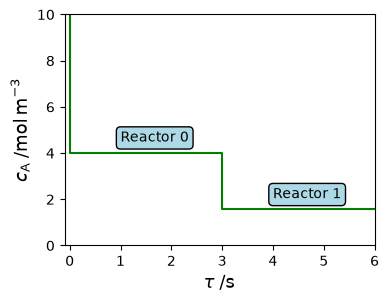

In [10]:
# Create figure and axes of plot
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Prepare values for plotting
c_A = np.insert(c_A, 0, c_A_in)  # insert inlet concentration as first entry
tau = np.cumsum(tau)  # build cumulative sum of residence times
tau = np.insert(arr=tau, obj=0, values=0)  # insert 0 as first entry

# Plot values
ax.step(tau, c_A, where="pre", color="green")

# Set axes parameters
ax.set_ylabel("$c_{\\mathregular{A}} \\; \\mathregular{/mol \\, m^{-3}}$", fontsize=13)
ax.set_xlabel("$\\tau \\; \\mathregular{/s}$", fontsize=13)
ax.set_ylim(0, 10)
ax.set_xlim(-0.1, max(tau))
ax.text(
    1,
    4.5,
    "Reactor 0",
    bbox={"facecolor": "lightblue", "edgecolor": "black", "boxstyle": "round"},
)
ax.text(
    4,
    2.05,
    "Reactor 1",
    bbox={"facecolor": "lightblue", "edgecolor": "black", "boxstyle": "round"},
)

In [11]:
def calculate_CSTR_cascade(c_A_in, k, n, tau_overall, N):
    """
    A function to calculate a CSTR cascade

    Args:
        c_A_in : inlet concentration [mol/m^3]
        k : reaction constant [1/(mol/m^3)(n-1)]
        n : reaction order
        tau_overall : overall residence time [s]
        N : number of CSTRs with equal tau

    Returns:
        arrays of residence times and concentrations for cascade plot
    """
    # define residence time of a single CSTR
    tau_single = tau_overall / N

    # CSTR species balance of A
    def CSTR_cascade(c_A):
        eq = np.zeros(N)
        eq[0] = (c_A_in - c_A[0]) + tau_single * (-k * c_A[0] ** n)  # CSTR 0
        for i in range(1, N):
            eq[i] = (c_A[i - 1] - c_A[i]) + tau_single * (
                -k * c_A[i] ** n
            )  # CSTRs 1 to N
        return eq

    # solving species balance of cascade
    c_A = fsolve(CSTR_cascade, np.linspace(c_A_in, 0, N))

    # prepare values for plotting
    c_A = np.insert(c_A, 0, c_A_in)  # insert inlet concentration as first entry
    tau = np.linspace(0, tau_overall, N + 1)

    return tau, c_A

In [12]:
import warnings

from ipywidgets import interact

warnings.simplefilter("ignore", RuntimeWarning)


@interact(N=(1, 100, 1))
def plot_cstr_cascade(N=1):
    c_A_in = 10  # [mol/m^3]
    k = 0.001  # [1/s]
    n = 1  # [-]
    tau_overall = 500  # [s]

    # generate plot
    _, ax = plt.subplots(1, 1, figsize=(4, 3))

    # define colors
    color = plt.get_cmap("Dark2")(np.linspace(0, 1, 4))[0]
    tau, c_A = calculate_CSTR_cascade(c_A_in, k, n, tau_overall, N)
    ax.step(tau, c_A, where="pre", color=color, label=f"$N={N}$")

    # axis label
    ax.set_xlabel(r"$\tau \; \mathregular{/s}$")
    ax.set_ylabel(r"$c_{\mathregular{A}} \; \mathregular{/mol \, m^{-3}}$")
    ax.set_xlim(-10, tau_overall)
    ax.set_ylim(0, 10)
    plt.show()

interactive(children=(IntSlider(value=1, description='N', min=1), Output()), _dom_classes=('widget-interact',)…